# 📈 Chương 3 — Dataset 1: Stock Market Sentiment — Vanilla RNN
## Kỹ thuật: Tokenization + Word Embedding + Vanilla RNN

**Pipeline:** EDA → WordCloud → Tokenize → Embedding → RNN → Train → Evaluate

---

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import re, os, warnings

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR = '../data/stock_sentiment'
SAVE_DIR = '../results/stock_sentiment'
os.makedirs(SAVE_DIR, exist_ok=True)

VOCAB_SIZE  = 10000
MAX_LEN     = 50
EMBED_DIM   = 64
EPOCHS      = 10
BATCH_SIZE  = 32

print(f'TF: {tf.__version__}')

TF: 2.21.0


## 📂 1. Load & Explore Data

In [2]:
# Load CSV — try common filenames
import glob
csv_files = glob.glob(f'{DATA_DIR}/**/*.csv', recursive=True) + glob.glob(f'{DATA_DIR}/*.csv')
print('Found CSV files:', csv_files)
df = pd.read_csv(csv_files[0])
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Found CSV files: ['../data/stock_sentiment/stock_data.csv', '../data/stock_sentiment/stock_data.csv']
Shape: (5791, 2)
Columns: ['Text', 'Sentiment']


,Text,Sentiment
0,Kickers on my watchlist XIDE TIT SOQ PNK CPW B...,1
1,user: AAP MOVIE. 55% return for the FEA/GEED i...,1
2,user I'd be afraid to short AMZN - they are lo...,1
3,MNTA Over 12.00,1
4,OI Over 21.37,1


In [3]:
# Identify text and label columns
# Common patterns: 'text'/'headline'/'sentence' and 'sentiment'/'label'
text_col  = [c for c in df.columns if any(k in c.lower() for k in ['text','headline','sentence','news'])][0]
label_col = [c for c in df.columns if any(k in c.lower() for k in ['sentiment','label','class'])][0]
print(f'Text column  : {text_col}')
print(f'Label column : {label_col}')
print(f'Label distribution:\n{df[label_col].value_counts()}')

Text column  : Text
Label column : Sentiment
Label distribution:
Sentiment
 1    3685
-1    2106
Name: count, dtype: int64


In [4]:
# Drop nulls and rename
df = df[[text_col, label_col]].dropna()
df.columns = ['text', 'label']

# Normalize labels to 0/1 if needed
unique_labels = sorted(df['label'].unique())
if set(unique_labels) != set(range(len(unique_labels))):
    label_map = {v: i for i, v in enumerate(unique_labels)}
    df['label'] = df['label'].map(label_map)
    print('Label mapping:', label_map)

print(f'Final shape: {df.shape}')
print(df['label'].value_counts())

Label mapping: {np.int64(-1): 0, np.int64(1): 1}
Final shape: (5791, 2)
label
1    3685
0    2106
Name: count, dtype: int64


## 📊 2. EDA — Phân tích văn bản

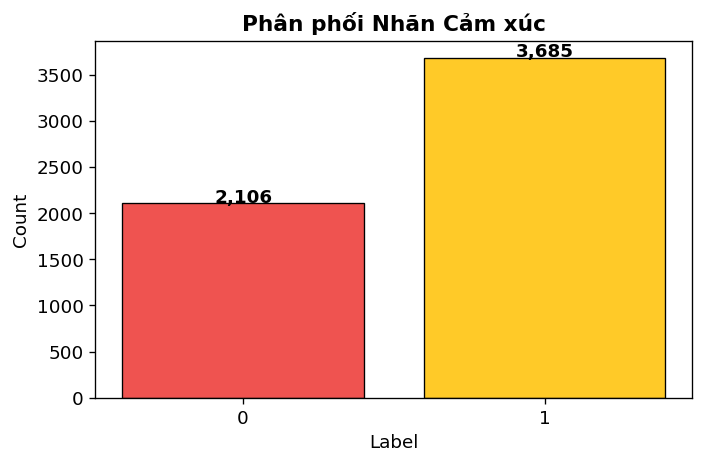

In [5]:
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))

# 1. Phân phối Nhãn Cảm xúc
plt.figure(figsize=(6, 4))
label_names = [str(v) for v in sorted(df['label'].unique())]
counts = df['label'].value_counts().sort_index()
bars = plt.bar(label_names, counts.values,
               color=['#EF5350','#FFCA28','#66BB6A'][:len(label_names)],
               edgecolor='black', linewidth=0.8)
plt.title('Phân phối Nhãn Cảm xúc')
plt.ylabel('Count')
plt.xlabel('Label')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_a_label_dist.png', bbox_inches='tight')
plt.show()

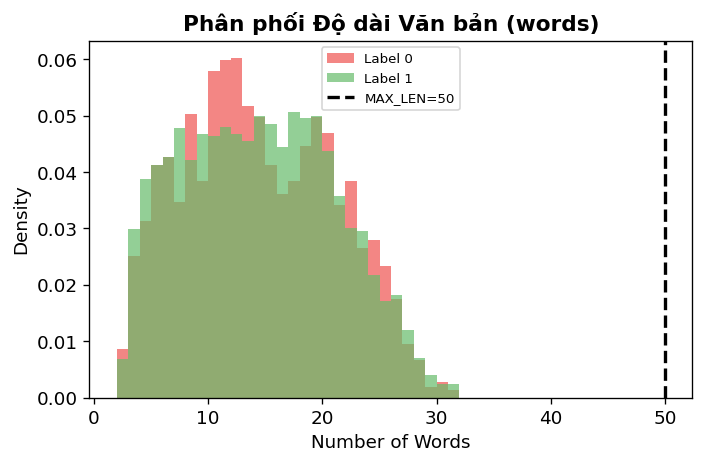

In [6]:
# 2. Phân phối Độ dài Văn bản (words)
plt.figure(figsize=(6, 4))
for lbl, color in zip(sorted(df['label'].unique()), ['#EF5350','#66BB6A','#42A5F5']):
    plt.hist(df[df['label']==lbl]['text_len'], bins=30, alpha=0.7,
             color=color, label=f'Label {lbl}', density=True)
plt.axvline(MAX_LEN, color='black', linestyle='--', lw=2, label=f'MAX_LEN={MAX_LEN}')
plt.title('Phân phối Độ dài Văn bản (words)')
plt.xlabel('Number of Words')
plt.ylabel('Density')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_b_textlen_dist.png', bbox_inches='tight')
plt.show()

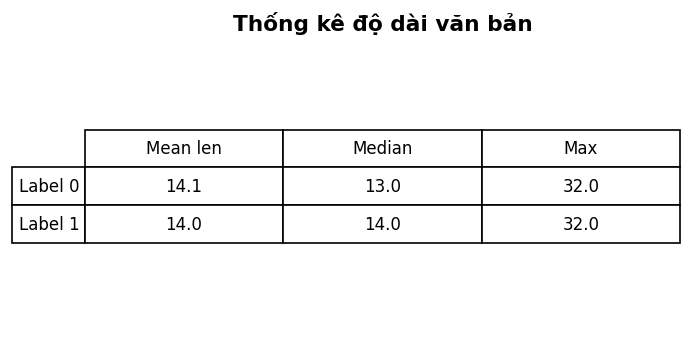

In [7]:
# 3. Thống kê độ dài văn bản
fig, ax = plt.subplots(figsize=(6, 3))
stats = df.groupby('label')['text_len'].describe()[['mean','50%','max']]
ax.axis('off')
table = ax.table(cellText=stats.round(1).values,
                 rowLabels=[f'Label {i}' for i in stats.index],
                 colLabels=['Mean len', 'Median', 'Max'],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
ax.set_title('Thống kê độ dài văn bản')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_c_textlen_stats.png', bbox_inches='tight')
plt.show()

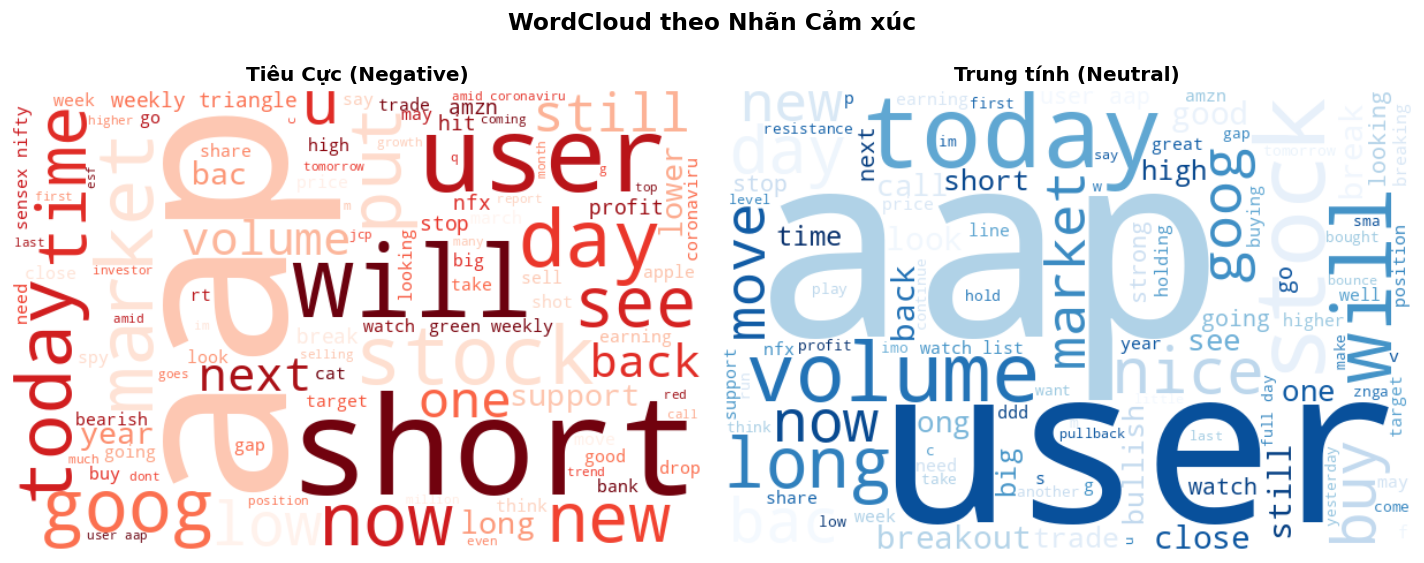

In [8]:
# WordCloud per label
unique_labels = sorted(df['label'].unique())
label_titles  = {0: 'Tiêu Cực (Negative)', 1: 'Trung tính (Neutral)', 2: 'Tích Cực (Positive)'}
label_colors  = {0: 'Reds', 1: 'Blues', 2: 'Greens'}

fig, axes = plt.subplots(1, len(unique_labels), figsize=(6*len(unique_labels), 5))
if len(unique_labels) == 1:
    axes = [axes]

for ax, lbl in zip(axes, unique_labels):
    text_corpus = ' '.join(df[df['label']==lbl]['text'].astype(str).tolist())
    # Remove common stopwords manually
    text_corpus = re.sub(r'[^a-zA-Z\s]', '', text_corpus.lower())
    wc = WordCloud(width=600, height=400,
                   max_words=100,
                   colormap=label_colors.get(lbl, 'viridis'),
                   background_color='white').generate(text_corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label_titles.get(lbl, f'Label {lbl}'), fontsize=12)

plt.suptitle('WordCloud theo Nhãn Cảm xúc', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_wordclouds.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing — Tokenize & Pad

In [9]:
import re, os, warnings
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# 1. Loại bỏ các từ phủ định ra khỏi danh sách Stopwords của sklearn để KHÔNG xóa chúng
safelist = {'not', 'no', 'nor', 'cannot', 'none'} 
SAFE_STOPWORDS = set(ENGLISH_STOP_WORDS) - safelist

# 2. Tập nhiễu tài chính: Chỉ giữ lại các từ thực sự không có ý nghĩa (bỏ các từ như good, dont, short, long, time ra)
DOMAIN_NOISE = {
    'user', 'aap', 'goog', 'stock', 'market', 'today', 'day', 'will', 'now', 'see', 'share', 'amzn', 
    'nfx', 'bac', 'spy', 'nifty', 'sensex', 'report', 'volume', 'one', 'going', 'go', 'still'
    # Các từ thời gian cơ bản hoặc lóng vô nghĩa
    'yesterday', 'tomorrow', 'im' 
}

# 3. Gộp lại
STOPWORDS_AND_NOISE = SAFE_STOPWORDS.union(DOMAIN_NOISE)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Bỏ URL
    text = re.sub(r'\$\w+', '', text)                 # Bỏ Ticker
    text = re.sub(r'[^a-z\s]', '', text)              # Bỏ ký tự đặc biệt (giữ lại chữ và khoảng trắng)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Chỉ lọc những từ thực sự vô nghĩa
    words = [w for w in text.split() if w not in STOPWORDS_AND_NOISE]
    return ' '.join(words)


In [10]:
# def clean_text(text):
#     text = str(text).lower()
#     text = re.sub(r'[^a-z\s]', '', text)
#     text = re.sub(r'\s+', ' ', text).strip()
#     return text

df['clean_text'] = df['text'].apply(clean_text)

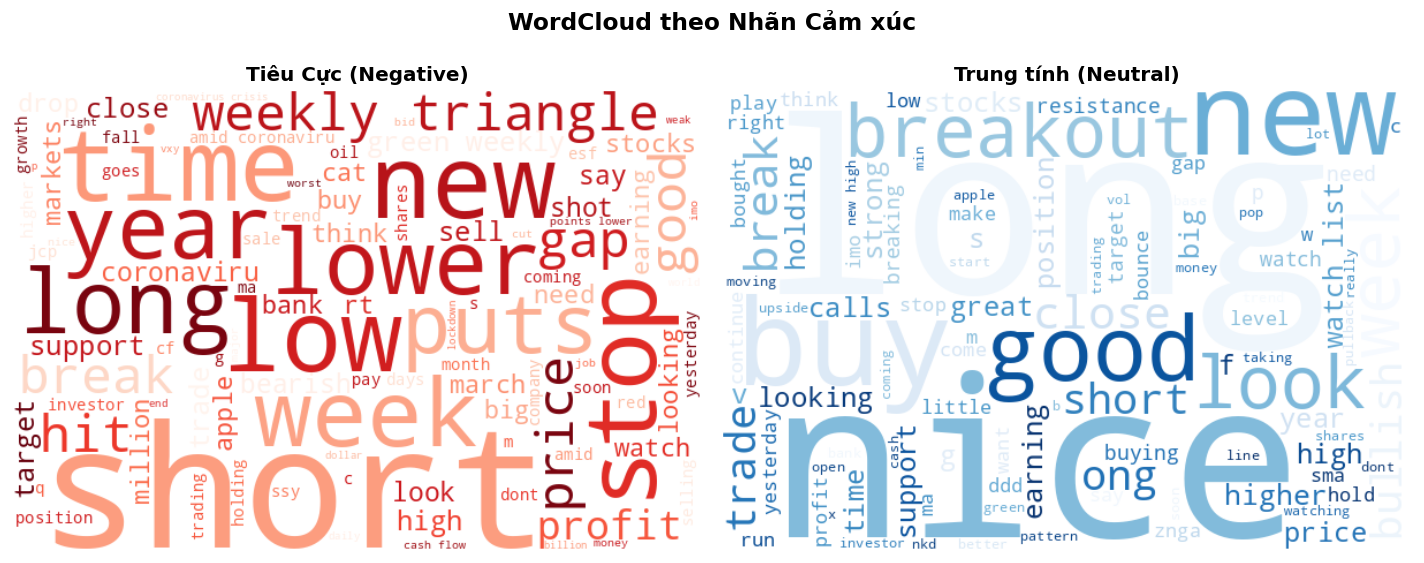

In [11]:
# WordCloud per label
unique_labels = sorted(df['label'].unique())
label_titles  = {0: 'Tiêu Cực (Negative)', 1: 'Trung tính (Neutral)', 2: 'Tích Cực (Positive)'}
label_colors  = {0: 'Reds', 1: 'Blues', 2: 'Greens'}

fig, axes = plt.subplots(1, len(unique_labels), figsize=(6*len(unique_labels), 5))
if len(unique_labels) == 1:
    axes = [axes]

for ax, lbl in zip(axes, unique_labels):
    # SỬA DÒNG NÀY: Thay 'text' bằng 'clean_text' để lấy văn bản đã được lọc sạch
    text_corpus = ' '.join(df[df['label']==lbl]['clean_text'].astype(str).tolist())
    
    # Loại bỏ regex thừa vì clean_text đã dọn dẹp cực kỳ sạch sẽ rồi
    wc = WordCloud(width=600, height=400,
                   max_words=100,
                   colormap=label_colors.get(lbl, 'viridis'),
                   background_color='white').generate(text_corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label_titles.get(lbl, f'Label {lbl}'), fontsize=12)

plt.suptitle('WordCloud theo Nhãn Cảm xúc', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_wordclouds.png', bbox_inches='tight')
plt.show()

In [12]:
X = df['clean_text'].values
y = df['label'].values
NUM_CLASSES = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# Tokenize
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='pre', truncating='pre')

print(f'Vocab size (actual): {len(tokenizer.word_index):,}')
print(f'Train: {X_train_seq.shape}, Test: {X_test_seq.shape}')
print(f'Num classes: {NUM_CLASSES}')

Vocab size (actual): 7,581
Train: (4632, 50), Test: (1159, 50)
Num classes: 2


In [13]:
# Visualize tokenization
sample_idx = 0
print('=== TOKENIZATION DEMO ===')
print(f'Original  : {X_train[sample_idx]}')
print(f'Cleaned   : {df["clean_text"].iloc[sample_idx]}')
print(f'Token IDs : {X_train_seq[sample_idx][:20]}...')
print(f'Padding   : {(X_train_seq[0] == 0).sum()} zero-padded positions')

# Coverage analysis
oov_rate = (X_train_seq == 1).sum() / X_train_seq.size
print(f'\nOOV rate in train: {oov_rate:.4f}')

=== TOKENIZATION DEMO ===
Original  : tcs price jumps no layoffs dividend announcements buy sell hold
Cleaned   : kickers watchlist xide tit soq pnk cpw bpz aj trade method method prev posts
Token IDs : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]...
Padding   : 40 zero-padded positions

OOV rate in train: 0.0000


## 🏗️ 4. Xây dựng Vanilla RNN Model

In [14]:
if NUM_CLASSES == 2:
    output_units, loss_fn, activation = 1, 'binary_crossentropy', 'sigmoid'
else:
    output_units, loss_fn, activation = NUM_CLASSES, 'sparse_categorical_crossentropy', 'softmax'

model = models.Sequential([
    layers.Input(shape=(MAX_LEN,), dtype='int32', name='input_layer'),
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN, name='embedding'),
    # Cải tiến 1: SpatialDropout1D chống Overfitting trên Word Embeddings cực tốt
    layers.SpatialDropout1D(0.3, name='spatial_dropout'),
    
    # Cải tiến 2: Bidirectional SimpleRNN giúp học ngữ cảnh 2 chiều
    layers.Bidirectional(layers.SimpleRNN(32, return_sequences=True), name='bidirectional_rnn_1'),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.SimpleRNN(16, return_sequences=True), name='bidirectional_rnn_2'),
    
    # Cải tiến 3: GlobalMaxPooling1D chắt lọc từ khóa quan trọng nhất của câu
    layers.GlobalMaxPooling1D(name='global_max_pooling'),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-3), name='dense_hidden'),
    layers.Dropout(0.3),
    layers.Dense(output_units, activation=activation, name='output')
], name='VanillaRNN_StockSentiment')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=loss_fn,
              metrics=['accuracy'])
model.summary()

Model: "VanillaRNN_StockSentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 50, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_rnn_1             │ (None, 50, 64)         │         6,208 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_rnn_2             │ (None, 50, 32)         │         2,592 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling              │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,889 (2.48 MB)

 Trainable params: 649,889 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

## 🚀 5. Training

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf

# 1. Tính toán trọng số để bù trừ sự mất cân bằng dữ liệu
# Lớp nào có số lượng ít sẽ được gắn trọng số lớn hơn để mô hình "chú ý" hơn
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

print(f"Đã áp dụng Class Weights: {class_weights}")

# 2. Huấn luyện mô hình với class_weight
history = model.fit(
    X_train_seq, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True, monitor='val_loss'),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ],
    verbose=1
)


Đã áp dụng Class Weights: {0: np.float64(1.3744807121661722), 1: np.float64(0.7858839497794368)}
Epoch 1/10


116/116 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.4891 - loss: 0.7399 - val_accuracy: 0.6278 - val_loss: 0.7145 - learning_rate: 0.0010
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5107 - loss: 0.7231 - val_accuracy: 0.6494 - val_loss: 0.7062 - learning_rate: 0.0010
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6076 - loss: 0.6812 - val_accuracy: 0.7120 - val_loss: 0.6173 - learning_rate: 0.0010
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8065 - loss: 0.4804 - val_accuracy: 0.7411 - val_loss: 0.5726 - learning_rate: 0.0010
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8993 - loss: 0.3072 - val_accuracy: 0.7184 - val_loss: 0.7103 - learning_rate: 0.0010
Epoch 6/10
115/116 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9343 - loss: 0.2311
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9360 - loss: 0.2176 - val_

## 📈 6. Phân tích Kết quả

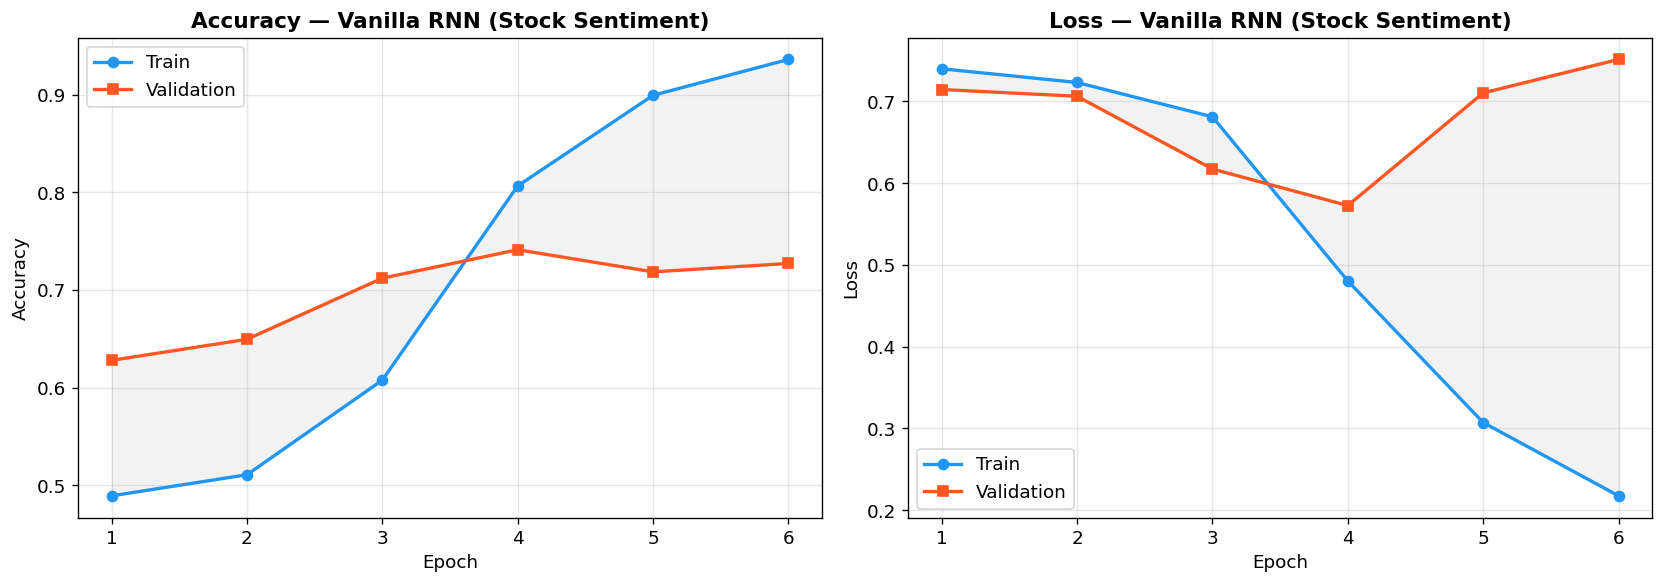

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history.history['accuracy'])+1)

for ax, (tr, vl, metric) in zip(axes, [
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('loss',     'val_loss',     'Loss')
]):
    ax.plot(eps, history.history[tr], 'o-', color='#2196F3', lw=2, label='Train')
    ax.plot(eps, history.history[vl], 's-', color='#FF5722', lw=2, label='Validation')
    ax.fill_between(eps, history.history[tr], history.history[vl], alpha=0.1, color='gray')
    ax.set_title(f'{metric} — Vanilla RNN (Stock Sentiment)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()

              precision    recall  f1-score   support

     Class 0       0.72      0.56      0.63       421
     Class 1       0.78      0.88      0.82       738

    accuracy                           0.76      1159
   macro avg       0.75      0.72      0.73      1159
weighted avg       0.76      0.76      0.75      1159



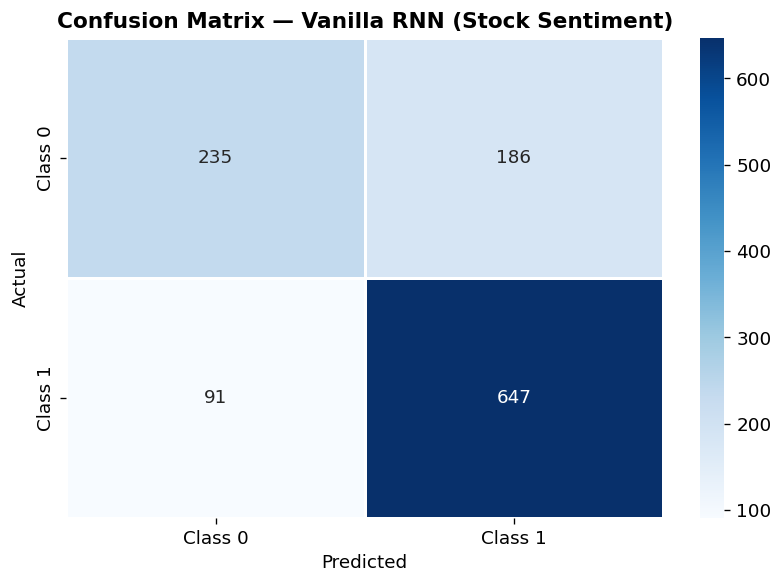

In [17]:
# Evaluation
y_pred_raw = model.predict(X_test_seq, verbose=0)
if NUM_CLASSES == 2:
    y_pred = np.where(y_pred_raw.flatten() >= 0.5, 1, 0)
else:
    y_pred = np.argmax(y_pred_raw, axis=1)

target_names = [f'Class {i}' for i in range(NUM_CLASSES)]
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.8, ax=ax)
ax.set_title('Confusion Matrix — Vanilla RNN (Stock Sentiment)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_matrix.png', bbox_inches='tight')
plt.show()

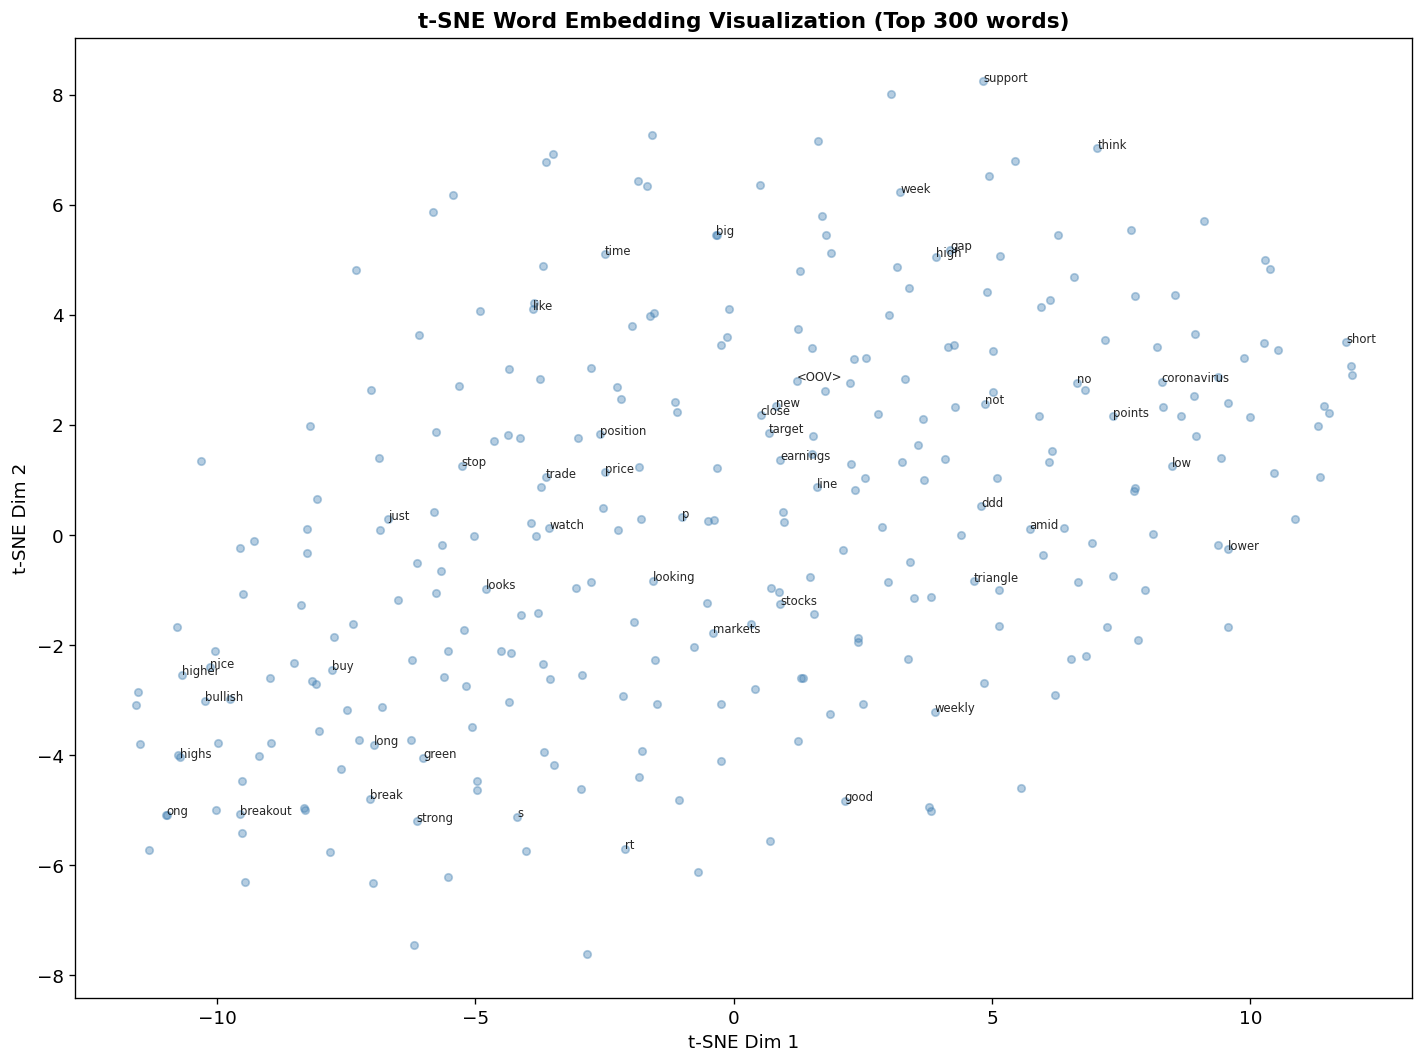

In [18]:
from sklearn.manifold import TSNE

embedding_weights=model.get_layer('embedding').get_weights()[0]

top_n=300
top_words=list(tokenizer.word_index.keys())[:top_n]
top_vecs=embedding_weights[1:top_n+1]

tsne=TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=30,
    max_iter=500
)

reduced=tsne.fit_transform(top_vecs)

plt.figure(figsize=(12,9))
plt.scatter(reduced[:,0],reduced[:,1],alpha=.4,s=20,color='steelblue')

for i,w in enumerate(top_words[:50]):
    plt.annotate(w,(reduced[i,0],reduced[i,1]),fontsize=7,alpha=.85)

plt.title('t-SNE Word Embedding Visualization (Top 300 words)',fontweight='bold')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_embedding_tsne.png',dpi=300,bbox_inches='tight')
plt.show()

In [19]:
best_val_acc = max(history.history['val_accuracy'])
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Stock Sentiment — Vanilla RNN\n' + '='*50 + '\n')
    f.write(f'Best Val Accuracy: {best_val_acc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_test, y_pred, target_names=target_names))

print('✅ Stock Sentiment RNN Experiment Done! Saved to', SAVE_DIR)

✅ Stock Sentiment RNN Experiment Done! Saved to ../results/stock_sentiment
